# 1. Project Setup

This notebook converts machine learning predictions into actionable business insights.

The objectives are to:

- Generate customer-level churn risk profiles.
- Analyze revenue exposure due to churn.
- Identify high-risk customer segments.
- Recommend retention strategies.
- Prepare datasets for business dashboards.
- Summarize key findings for executive decision-making.

In [1]:
# ==========================================================
# Project Setup
# ==========================================================

# Standard Library
import warnings
import sys
from pathlib import Path

# Third-Party Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Local Modules
from src.config.paths import (
    ARTIFACTS_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    REPORTS_DASHBOARD_DIR,
    REPORTS_FIGURES_DIR,
    PROCESSED_DATA_DIR
)

from src.config.settings import RANDOM_STATE, TARGET_COLUMN
from src.business.artifact_loader import load_business_artifacts
from src.business.customer_personas import build_customer_personas

warnings.filterwarnings("ignore")

# Plot configuration
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Reproducibility
np.random.seed(RANDOM_STATE)

print("Project setup completed successfully.")

Project setup completed successfully.


In [2]:
# ==========================================================
# Load Saved Artifacts & Build Business Dataset
# ==========================================================

artifacts = load_business_artifacts()

model = artifacts["model"]
preprocessor = artifacts["preprocessor"]
feature_importance = artifacts["feature_importance"]
shap_values = artifacts["shap_values"]
df = artifacts["df"]
df_business = artifacts["df_business"]

# Run K-Means Clustering on the business dataset to assign personas
df_business = build_customer_personas(df_business)

print("Artifacts loaded and customer personas generated successfully.")

Artifacts loaded and customer personas generated successfully.


## 2. Revenue Risk KPI Analysis

Consolidating and summarizing Monthly Recurring Revenue (MRR) exposure and predicted losses.

In [3]:
from src.business.revenue_analysis import (
    calculate_revenue_kpis,
    revenue_by_segment,
    revenue_by_contract,
    revenue_by_service,
    create_revenue_dashboard
)

# Calculate high-level KPIs
kpis = calculate_revenue_kpis(df, model, preprocessor)

print("=" * 60)
print("TELCO CHURN FINANCIAL & REVENUE RISK OVERVIEW")
print("=" * 60)
for kpi, val in kpis.items():
    if "Rate" in kpi:
        print(f"{kpi:<35} : {val:.2%}")
    elif "Revenue" in kpi or "MRR" in kpi:
        print(f"{kpi:<35} : ${val:,.2f}")
    else:
        print(f"{kpi:<35} : {val:,}")
print("=" * 60)

TELCO CHURN FINANCIAL & REVENUE RISK OVERVIEW
Total Customers                     : 7,021
Total Monthly Revenue (MRR)         : $455,325.15
Expected Monthly Revenue Loss       : $212,660.10
High Risk Monthly Revenue Loss      : $220,462.85
Expected Churn Rate                 : 41.30%
Actual Churn Rate                   : 26.45%


In [4]:
print("Revenue Loss by Contract Type:")
display(revenue_by_contract(df, model, preprocessor))

print("\nRevenue Loss by Subscribed Services:")
display(revenue_by_service(df, model, preprocessor))

Revenue Loss by Contract Type:


,Contract Type,Customer Count,Total MRR,Expected MRR Loss,Avg Churn Probability
0,Month-to-Month,3853,256502.70,173515.102973,0.626682
1,One Year,1473,95816.60,28407.085200,0.242635
2,Two Year,1695,103005.85,10737.916074,0.075125



Revenue Loss by Subscribed Services:


,Service,Customer Count,Total MRR,Expected MRR Loss,Avg Churn Probability
0,Fiber Optic Internet,3090,282866.10,167337.680719,0.608238
1,DSL Internet,2419,140574.35,40705.570023,0.328832
2,Online Security Add-on,2019,159175.40,46220.623200,0.281250
3,Online Backup Add-on,2429,201805.20,77019.059471,0.370873
4,Device Protection Add-on,2422,205439.50,80054.954844,0.375531
5,Tech Support Add-on,2044,164910.20,49478.379876,0.289774


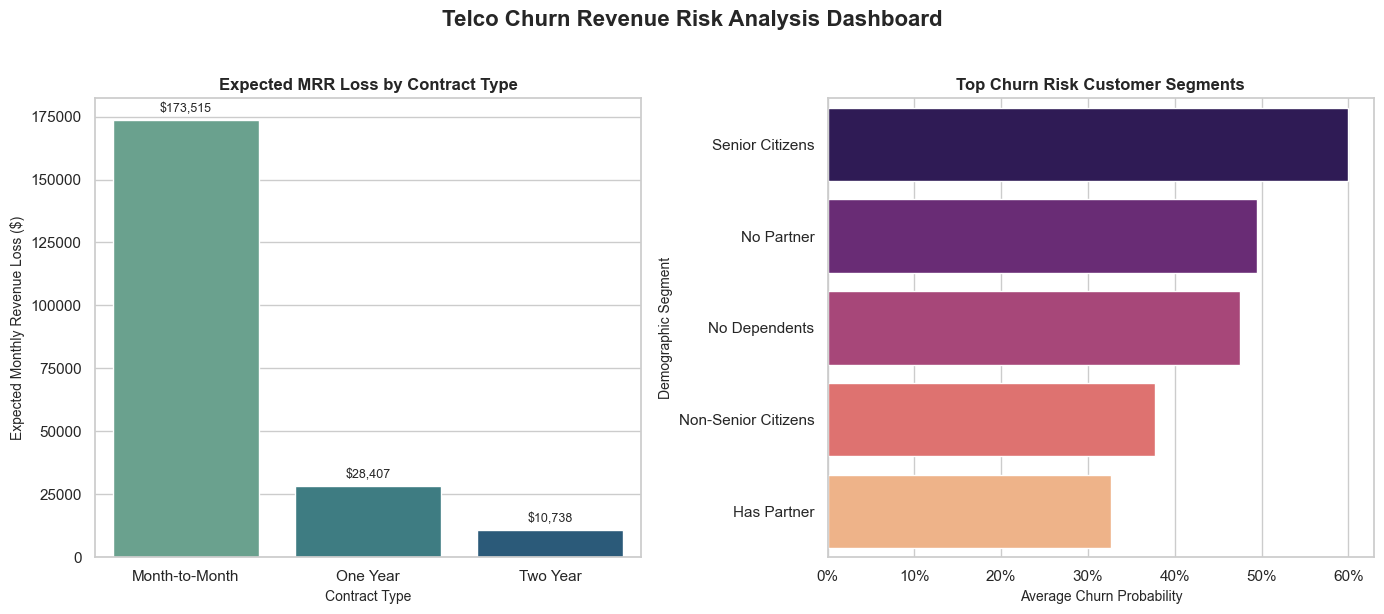

In [5]:
from src.config.paths import REPORTS_DIR
figures_dir = REPORTS_FIGURES_DIR

# Renders and exports revenue risk dashboard figure
create_revenue_dashboard(df, model, preprocessor, figures_dir)

## 3. Churn Driver & Directional Analysis

Evaluating top churn risk drivers and their direction of impact on customer churn.

In [6]:
from src.business.churn_driver_analysis import (
    top_churn_drivers,
    positive_driver_summary,
    negative_driver_summary,
    driver_category_summary,
    driver_importance_chart,
    driver_report
)

# Print Churn Driver Analysis Report
driver_report(feature_importance, model)

CHURN DRIVER ANALYSIS REPORT

Top 3 Drivers INCREASING Churn Risk:
  - tenure                         (SHAP: 1.0964, Model Rank: 1)
  - TotalCharges                   (SHAP: 0.4568, Model Rank: 4)
  - InternetService_DSL            (SHAP: 0.2503, Model Rank: 5)

Top 3 Drivers REDUCING Churn Risk (Retention Anchors):
  - Contract_Two year              (SHAP: 0.4446, Model Rank: 2)
  - SecurityRisk                   (SHAP: 0.2586, Model Rank: 14)
  - StreamingUser                  (SHAP: 0.1966, Model Rank: 16)



In [7]:
print("Driver Category Summary:")
display(driver_category_summary(feature_importance, model))

print("\nTop 5 Positive Drivers (Increases Churn Risk):")
display(positive_driver_summary(feature_importance, model, limit=5))

print("\nTop 5 Negative Drivers (Reduces Churn Risk / Retention Anchors):")
display(negative_driver_summary(feature_importance, model, limit=5))

Driver Category Summary:


,Feature_Count,Avg_Model_Importance,Avg_SHAP_Importance,Avg_Perm_Importance
Category,,,,
Charges & Spending,3,0.1803,0.1523,0.0053
Contract Term,3,0.6425,0.2481,-0.0014
Demographics,7,0.0404,0.0220,0.0000
Services & Add-ons,37,0.1524,0.0880,0.0035



Top 5 Positive Drivers (Increases Churn Risk):


,Feature,Model Importance,Relative Importance (%),Rank_Model,Mean |SHAP Value|,Rank_SHAP,Permutation Importance,Rank_Permutation,Direction
0,tenure,1.232272,100.000000,1,1.096361,1,0.101823,1,Positive (Increases Churn)
3,TotalCharges,0.540914,43.895654,4,0.456750,2,0.015767,2,Positive (Increases Churn)
4,InternetService_DSL,0.520038,42.201558,5,0.250318,5,0.008888,3,Positive (Increases Churn)
7,StreamingMovies_Yes,0.331610,26.910449,8,0.162128,8,0.002407,9,Positive (Increases Churn)
23,OnlineSecurity_No,0.053706,4.358282,24,0.026859,22,-0.001481,48,Positive (Increases Churn)



Top 5 Negative Drivers (Reduces Churn Risk / Retention Anchors):


,Feature,Model Importance,Relative Importance (%),Rank_Model,Mean |SHAP Value|,Rank_SHAP,Permutation Importance,Rank_Permutation,Direction
1,Contract_Two year,1.216245,98.699349,2,0.444583,3,-0.005028,50,Negative (Reduces Churn)
13,SecurityRisk,0.269354,21.858277,14,0.258583,4,0.007563,4,Negative (Reduces Churn)
15,StreamingUser,0.196466,15.943418,16,0.196557,6,0.002834,7,Negative (Reduces Churn)
14,TotalServices,0.205280,16.658690,15,0.178529,7,0.001923,11,Negative (Reduces Churn)
9,PaperlessBilling_No,0.321015,26.050679,10,0.154559,9,-0.000798,44,Negative (Reduces Churn)


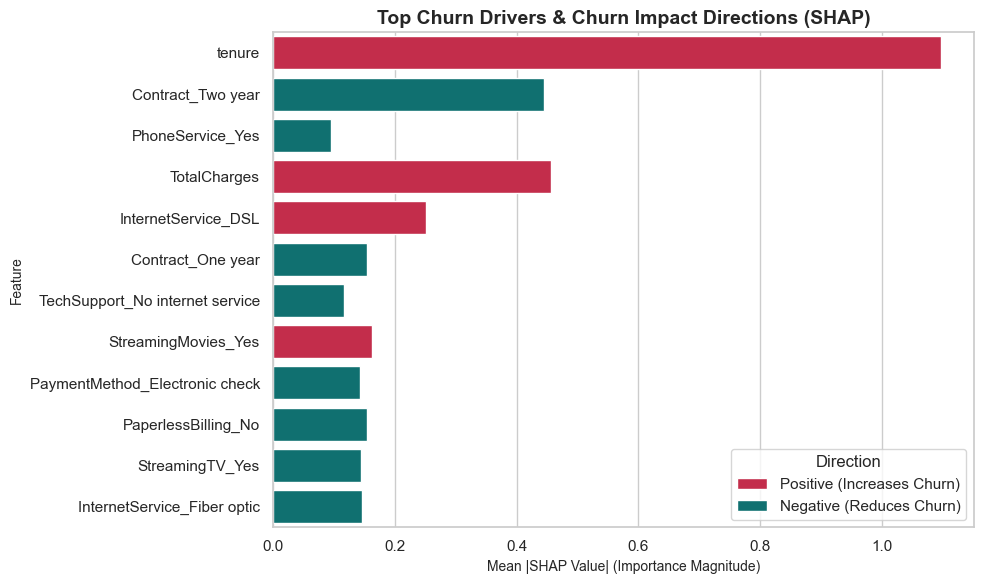

In [8]:
# Renders visual comparison chart of top drivers
driver_importance_chart(feature_importance, model, figures_dir)

## 4. Customer Portfolio Analysis

Analyzing customer segments, contract structures, demographics, and identifying top high-risk customer profiles.

In [9]:
from src.business.customer_portfolio import (
    portfolio_summary,
    contract_portfolio,
    internet_portfolio,
    payment_portfolio,
    demographic_profile,
    high_risk_customers
)

portfolio = portfolio_summary(df_business)
contract_analysis = contract_portfolio(df_business)
demographics = demographic_profile(df_business)

print("Customer Portfolio Summary Statistics:")
display(portfolio)

print("\nContract Portfolio Breakdown:")
display(contract_analysis)

print("\nDemographics Portfolio Breakdown:")
display(demographics)

Customer Portfolio Summary Statistics:


,Metric,Value
0,Total Customers,7021.000
1,High Risk Customers,3422.000
2,Critical Customers,1762.000
3,Average Customer Tenure,32.470
4,Average Monthly Charges,64.850
5,Average Churn Probability,0.413



Contract Portfolio Breakdown:


Risk_Segment,At Risk,Critical,Safe,Stable
Contract,,,,
Month-to-month,35.84,45.57,2.67,15.91
One year,18.74,0.41,49.49,31.36
Two year,0.18,0.00,91.45,8.38



Demographics Portfolio Breakdown:


,Customers,Avg_Tenure,Avg_Monthly_Charges,Avg_Churn_Probability
Risk_Segment,,,,
At Risk,1660,25.47,68.83,0.55
Critical,1762,12.81,80.43,0.81
Safe,2382,51.65,52.48,0.08
Stable,1217,32.93,61.07,0.30


In [10]:
print("Internet Portfolio Breakdown:")
display(internet_portfolio(df_business))

print("\nPayment Method Portfolio Breakdown:")
display(payment_portfolio(df_business))

Internet Portfolio Breakdown:


Risk_Segment,At Risk,Critical,Safe,Stable
InternetService,,,,
DSL,30.59,9.47,42.29,17.65
Fiber optic,25.83,49.61,10.97,13.59
No,8.07,0.00,67.46,24.47



Payment Method Portfolio Breakdown:


Risk_Segment,At Risk,Critical,Safe,Stable
PaymentMethod,,,,
Bank transfer (automatic),20.66,11.33,48.77,19.24
Credit card (automatic),19.97,9.46,52.43,18.13
Electronic check,27.38,53.67,7.93,11.02
Mailed check,24.50,11.09,40.35,24.06


In [11]:
print("Top 20 High-Risk Customer Snapshot for Retention Campaign Outreach:")
display(high_risk_customers(df_business, limit=20))

Top 20 High-Risk Customer Snapshot for Retention Campaign Outreach:


,CustomerID,Contract,InternetService,PaymentMethod,tenure,MonthlyCharges,Churn_Probability,Risk_Segment
4789,9300-AGZNL,Month-to-month,Fiber optic,Electronic check,1,94.00,0.942836,Critical
1971,9497-QCMMS,Month-to-month,Fiber optic,Electronic check,1,93.55,0.942830,Critical
3372,5178-LMXOP,Month-to-month,Fiber optic,Electronic check,1,95.10,0.942600,Critical
3741,4424-TKOPW,Month-to-month,Fiber optic,Electronic check,2,93.85,0.941435,Critical
6353,2720-WGKHP,Month-to-month,Fiber optic,Electronic check,2,94.00,0.941236,Critical
3152,5150-ITWWB,Month-to-month,Fiber optic,Electronic check,3,94.85,0.940487,Critical
1408,7024-OHCCK,Month-to-month,Fiber optic,Electronic check,2,93.85,0.939922,Critical
2203,7216-EWTRS,Month-to-month,Fiber optic,Electronic check,1,100.80,0.939520,Critical
5975,5567-WSELE,Month-to-month,Fiber optic,Electronic check,3,94.60,0.939469,Critical
996,1374-DMZUI,Month-to-month,Fiber optic,Electronic check,4,94.30,0.937627,Critical


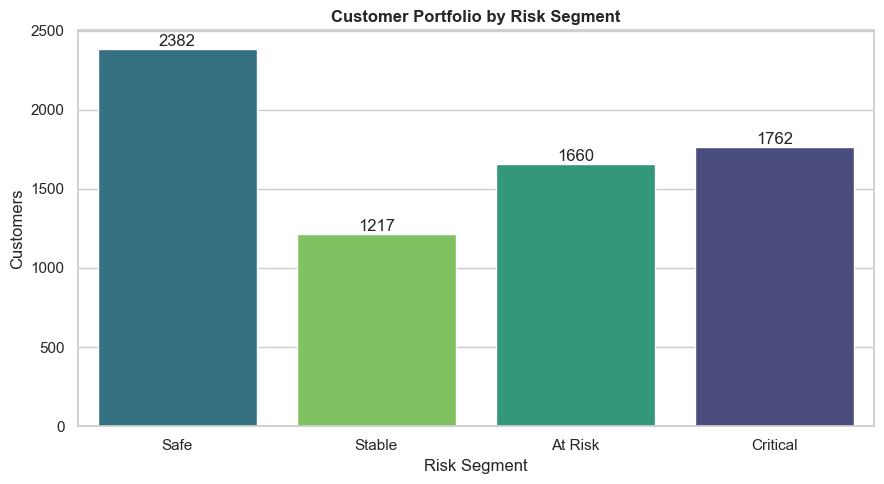

In [12]:
# Renders countplot of customer risk segments
plt.figure(figsize=(9,5))
ax = sns.countplot(
    data=df_business,
    x="Risk_Segment",
    hue="Risk_Segment",
    palette="viridis",
    order=["Safe", "Stable", "At Risk", "Critical"],
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Portfolio by Risk Segment", fontsize=12, fontweight="bold")
plt.xlabel("Risk Segment")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig(figures_dir / "customer_portfolio_segments.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

## 5. Data-Driven Customer Personas (Clustering)

Applying K-Means unsupervised clustering to automatically identify natural customer segments and profile their properties.

In [13]:
from src.business.customer_personas import (
    persona_distribution,
    persona_summary,
    persona_dashboard,
    persona_report
)

# Print Persona Executive Report
persona_report(df_business)

CUSTOMER PERSONAS EXECUTIVE REPORT (DATA-DRIVEN CLUSTERING)

Summary of Natural Customer Segments Discovered:

* Persona: High-Value At-Risk Customers
  - Size: 2027 customers (28.9%)
  - Average Tenure: 15.1 months
  - Average Monthly Spending: $84.02
  - Average Total Charges: $1315.17
  - Churn Risk Level: 76.0%
  - Strategy: Target with high-priority proactive retention, price freezes, and service guarantees.

* Persona: Loyal Long-Term Customers
  - Size: 1768 customers (25.2%)
  - Average Tenure: 60.5 months
  - Average Monthly Spending: $93.74
  - Average Total Charges: $5674.31
  - Churn Risk Level: 28.0%
  - Strategy: Target with loyalty rewards, cross-sell/up-sell premium services, and long-term extensions.

* Persona: New Price-Sensitive Customers
  - Size: 1755 customers (25.0%)
  - Average Tenure: 10.0 months
  - Average Monthly Spending: $36.43
  - Average Total Charges: $387.12
  - Churn Risk Level: 42.0%
  - Strategy: Offer flexible basic plans, discount bundles, or con

In [14]:
print("Persona Distribution Summary:")
display(persona_distribution(df_business))

print("\nPersona Summary Statistics:")
display(persona_summary(df_business))

Persona Distribution Summary:


,Persona,Customer Count,Percentage (%)
0,High-Value At-Risk Customers,2027,28.87
1,Loyal Long-Term Customers,1768,25.18
2,New Price-Sensitive Customers,1755,25.00
3,Stable Family Customers,1471,20.95



Persona Summary Statistics:


,Customer_Count,Avg_Tenure_Months,Avg_Monthly_Charges,Avg_Total_Charges,Avg_Churn_Probability
Persona,,,,,
High-Value At-Risk Customers,2027,15.09,84.02,1315.17,0.76
Loyal Long-Term Customers,1768,60.49,93.74,5674.31,0.28
New Price-Sensitive Customers,1755,10.02,36.43,387.12,0.42
Stable Family Customers,1471,49.52,37.63,1820.48,0.09


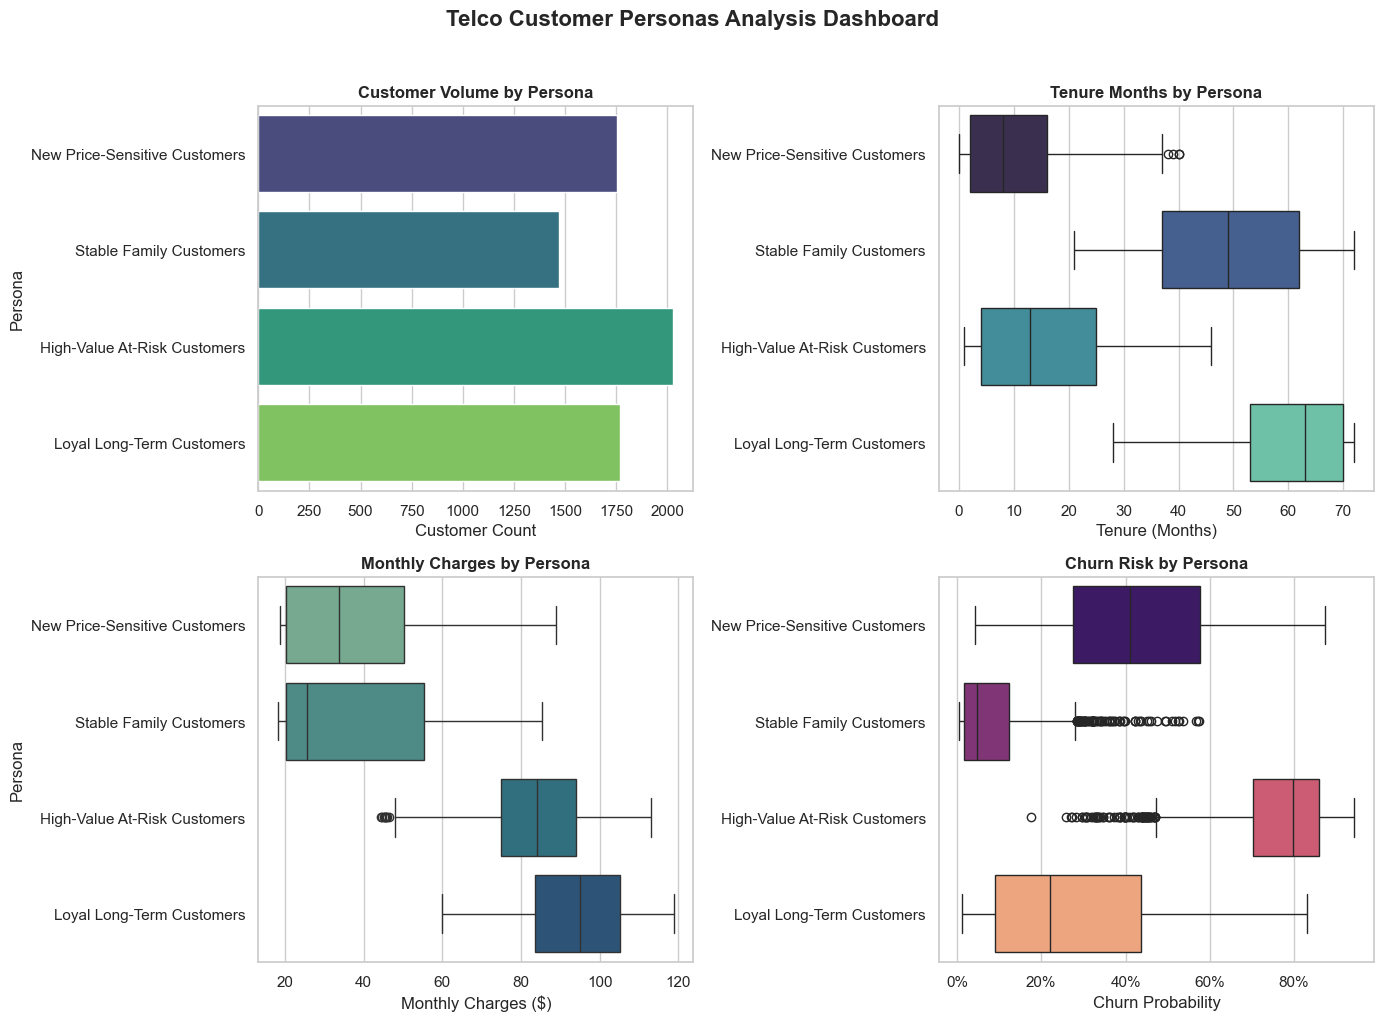

In [15]:
# Renders visual box/bar comparison dashboard of top personas
persona_dashboard(df_business, figures_dir)

## 6. Proactive Retention Strategy Engine

Applying strategic business recommendation rules based on risk levels and customer attributes to calculate campaign budgets and expected ROI.

In [16]:
from src.business.retention_engine import (
    generate_recommendations,
    recommendation_summary,
    high_priority_customers,
    recommendation_dashboard,
    recommendation_report
)

# Predict and append recommendations to df_business
df_business = generate_recommendations(df_business)

# Print Retention Campaign Strategic Report
recommendation_report(df_business)

RETENTION ENGINE SYSTEM CAMPAIGN STRATEGY REPORT

Overall Campaign Summary:
  - Total Target Customers: 7021 accounts
  - Expected MRR at Risk (Total Saved potential): $212,660.35
  - Estimated Retention Campaign Budget: $30,420.00
  - Estimated ROI: 6.99x (MRR Saved per Dollar Spent)

Breakdown by Recommended Campaign Action:

* Action: Account Review: Offer basic plan optimization
  - Target Accounts: 862 customers (12.3%)
  - Avg Churn Risk of Group: 54.0%
  - Expected MRR Saved: $21,932.03
  - Action Cost Budget: $0.00

* Action: Executive Call: Offer $15 loyalty credit
  - Target Accounts: 6 customers (0.1%)
  - Avg Churn Risk of Group: 72.0%
  - Expected MRR Saved: $415.93
  - Action Cost Budget: $90.00

* Action: Loyalty Engagement: Send thank-you summary email
  - Target Accounts: 3599 customers (51.3%)
  - Avg Churn Risk of Group: 15.0%
  - Expected MRR Saved: $33,505.12
  - Action Cost Budget: $0.00

* Action: Outbound Call: Offer 1-Yr Upgrade & $15/mo discount
  - Target Acc

In [17]:
print("Campaign Recommendation Summary:")
display(recommendation_summary(df_business))

print("\nTop 10 High-Priority Customers for Urgent Outreach:")
display(high_priority_customers(df_business, limit=10))

Campaign Recommendation Summary:


,Customers,Avg_Churn_Probability,Total_Monthly_Charges,Total_Priority_Score,Total_Action_Cost
Retention_Action,,,,,
Account Review: Offer basic plan optimization,862,0.54,40320.80,21932.03,0.0
Executive Call: Offer $15 loyalty credit,6,0.72,580.20,415.93,90.0
Loyalty Engagement: Send thank-you summary email,3599,0.15,199344.45,33505.12,0.0
Outbound Call: Offer 1-Yr Upgrade & $15/mo discount,1756,0.81,141135.25,115293.60,26340.0
Support Outreach: Offer 3-Mo Tech Support trial,798,0.56,73944.45,41513.67,3990.0



Top 10 High-Priority Customers for Urgent Outreach:


,CustomerID,tenure,MonthlyCharges,Churn_Probability,Risk_Segment,Persona,Priority_Score,Retention_Action
6873,1400-MMYXY,3,105.90,0.931658,Critical,High-Value At-Risk Customers,98.66,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
5919,6496-SLWHQ,3,105.00,0.931341,Critical,High-Value At-Risk Customers,97.79,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
261,3606-TWKGI,13,106.90,0.913765,Critical,High-Value At-Risk Customers,97.68,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
1565,3292-PBZEJ,11,111.40,0.875034,Critical,High-Value At-Risk Customers,97.48,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
4815,3389-YGYAI,8,105.50,0.921515,Critical,High-Value At-Risk Customers,97.22,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
2443,9221-OTIVJ,14,104.85,0.911268,Critical,High-Value At-Risk Customers,95.55,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
2289,2027-FECZV,12,106.70,0.894814,Critical,High-Value At-Risk Customers,95.48,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
3947,4587-VVTOX,6,105.30,0.904443,Critical,High-Value At-Risk Customers,95.24,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
3054,8118-LSUEL,23,106.40,0.893337,Critical,High-Value At-Risk Customers,95.05,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...
6350,8884-ADFVN,7,101.95,0.931233,Critical,High-Value At-Risk Customers,94.94,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...


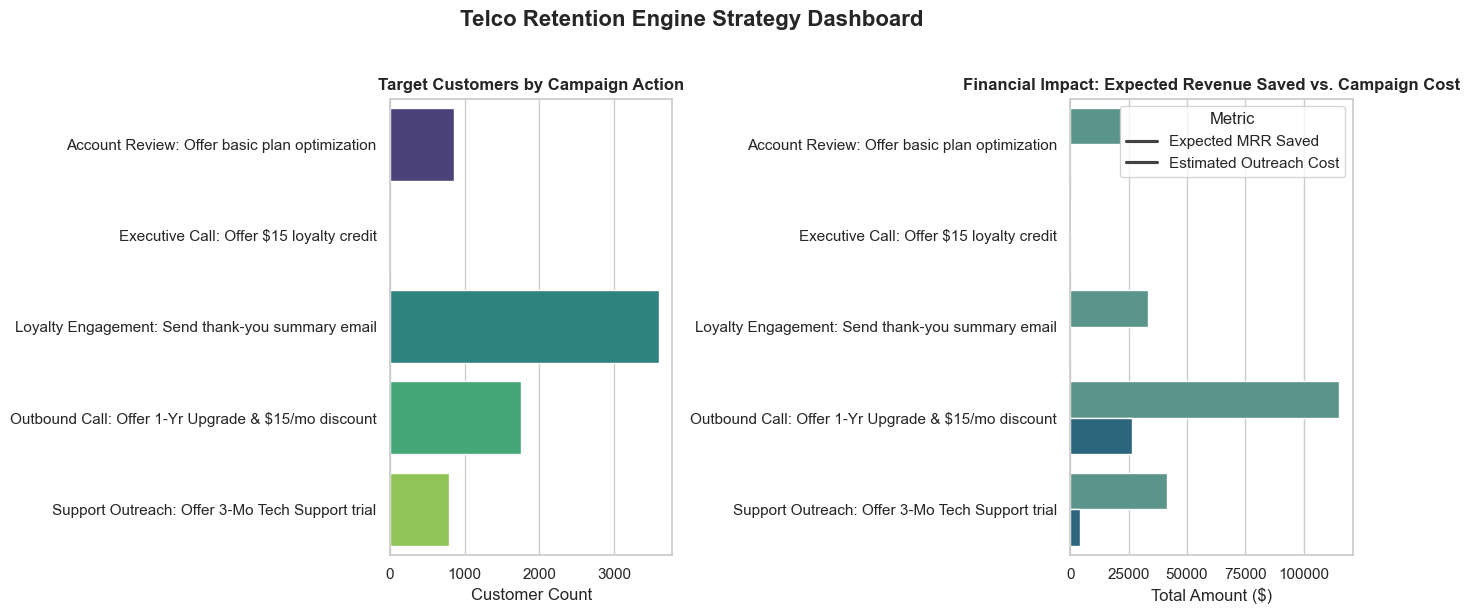

In [18]:
# Renders visual dashboard comparing campaign saved MRR vs budget costs
recommendation_dashboard(df_business, figures_dir)

## 7. Dashboard Dataset Export

Consolidating all enrichments (ML predictions, risk segments, personas, retention actions) into a single export-ready CSV for downstream Streamlit dashboards, Power BI, or API consumption.

In [19]:
from src.business.dashboard_export import (
    prepare_dashboard_dataset,
    dashboard_summary,
    export_dashboard_dataset
)

# Prepare the consolidated dashboard dataset
df_dashboard = prepare_dashboard_dataset(df_business)

# Print export summary
dashboard_summary(df_dashboard)

DASHBOARD DATASET EXPORT SUMMARY

  Total Records        : 7,021
  Total Columns        : 28

  Enrichment Coverage:
    - ML Churn Probability     : 7,021 / 7,021 (100.0%)
    - Risk Segment             : 7,021 / 7,021 (100.0%)
    - Customer Persona         : 7,021 / 7,021 (100.0%)
    - Retention Action         : 7,021 / 7,021 (100.0%)
    - Priority Score           : 7,021 / 7,021 (100.0%)

  Risk Segment Distribution:
    - Critical    : 1,762 customers (25.1%)
    - At Risk     : 1,660 customers (23.6%)
    - Stable      : 1,217 customers (17.3%)
    - Safe        : 2,382 customers (33.9%)

  Persona Distribution:
    - High-Value At-Risk Customers       : 2,027 (28.9%)
    - Loyal Long-Term Customers          : 1,768 (25.2%)
    - New Price-Sensitive Customers      : 1,755 (25.0%)
    - Stable Family Customers            : 1,471 (21.0%)



In [20]:
# Preview the first 10 rows of the dashboard dataset
print("Dashboard Dataset Preview (first 10 rows):")
display(df_dashboard.head(10))

Dashboard Dataset Preview (first 10 rows):


,CustomerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,PhoneService,...,MonthlyCharges,TotalCharges,Churn,Churn_Probability,Risk_Segment,Persona,Priority_Score,Retention_Action,Estimated_Action_Cost,Cluster
0,7590-VHVEG,Female,0,Yes,No,1,Month-to-month,Yes,Electronic check,No,...,29.85,29.85,No,0.8263,Critical,New Price-Sensitive Customers,24.66,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...,15.0,2
1,5575-GNVDE,Male,0,No,No,34,One year,No,Mailed check,Yes,...,56.95,1889.50,No,0.1045,Safe,Stable Family Customers,5.95,Loyalty Engagement: Send thank-you summary email,0.0,0
2,3668-QPYBK,Male,0,No,No,2,Month-to-month,Yes,Mailed check,Yes,...,53.85,108.15,Yes,0.4989,At Risk,New Price-Sensitive Customers,26.86,Account Review: Offer basic plan optimization,0.0,2
3,7795-CFOCW,Male,0,No,No,45,One year,No,Bank transfer (automatic),No,...,42.30,1840.75,No,0.1271,Safe,Stable Family Customers,5.38,Loyalty Engagement: Send thank-you summary email,0.0,0
4,9237-HQITU,Female,0,No,No,2,Month-to-month,Yes,Electronic check,Yes,...,70.70,151.65,Yes,0.8622,Critical,High-Value At-Risk Customers,60.95,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...,15.0,1
5,9305-CDSKC,Female,0,No,No,8,Month-to-month,Yes,Electronic check,Yes,...,99.65,820.50,Yes,0.9109,Critical,High-Value At-Risk Customers,90.77,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...,15.0,1
6,1452-KIOVK,Male,0,No,Yes,22,Month-to-month,Yes,Credit card (automatic),Yes,...,89.10,1949.40,No,0.7003,Critical,High-Value At-Risk Customers,62.40,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...,15.0,1
7,6713-OKOMC,Female,0,No,No,10,Month-to-month,No,Mailed check,No,...,29.75,301.90,No,0.5100,At Risk,New Price-Sensitive Customers,15.17,Account Review: Offer basic plan optimization,0.0,2
8,7892-POOKP,Female,0,Yes,No,28,Month-to-month,Yes,Electronic check,Yes,...,104.80,3046.05,Yes,0.7981,Critical,High-Value At-Risk Customers,83.65,Outbound Call: Offer 1-Yr Upgrade & $15/mo dis...,15.0,1
9,6388-TABGU,Male,0,No,Yes,62,One year,No,Bank transfer (automatic),Yes,...,56.15,3487.95,No,0.0339,Safe,Stable Family Customers,1.90,Loyalty Engagement: Send thank-you summary email,0.0,0


In [21]:
# Export to reports/ directory
export_path = export_dashboard_dataset(df_dashboard, REPORTS_DASHBOARD_DIR)

✅ Dashboard dataset exported successfully.
   Path     : D:\customer-churn-intelligence-platform\reports\dashboard\dashboard_dataset.csv
   Records  : 7,021
   Columns  : 28
   File Size: 1654.9 KB
